# 🗺️ Studi Kasus: Pencarian Rute Terbaik Semarang → Cilacap
## Menggunakan Algoritma Best First Search
**Nama:** Andri | **Asal:** Semarang (Kawasan Industri Wijayakusuma) | **Tujuan:** Cilacap

---
## 1. Import Library

In [ ]:
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from collections import defaultdict

Di sini kita import beberapa library yang dibutuhin. `heapq` dipake buat bikin **priority queue** — ini penting banget di Best First Search supaya kota yang paling deket ke tujuan selalu diproses duluan. Terus `matplotlib` sama `networkx` dipake buat **visualisasi graph**-nya, biar rute yang ditemuin keliatan lebih jelas dan menarik.

---
## 2. Input Data Jarak Antar Kota (Graf)

In [ ]:
# Graf berisi jarak antar kota (dalam km) — dua arah (undirected)
graph = defaultdict(dict)

edges = [
    ('Semarang',    'Demak',        29.0),
    ('Semarang',    'Kendal',       30.8),
    ('Semarang',    'Salatiga',     51.5),
    ('Salatiga',    'Temanggung',   55.6),
    ('Salatiga',    'Boyolali',     24.4),
    ('Temanggung',  'Magelang',     28.2),
    ('Temanggung',  'Wonosobo',     39.1),
    ('Temanggung',  'Kendal',       71.0),
    ('Magelang',    'Wonosobo',     58.4),
    ('Magelang',    'Purworejo',    44.1),
    ('Wonosobo',    'Banjarnegara', 47.3),
    ('Banjarnegara','Purbalingga',  28.2),
    ('Purworejo',   'Kebumen',      42.1),
    ('Kebumen',     'Kroya',        53.0),
    ('Kebumen',     'Purwokerto',   69.2),
    ('Purbalingga', 'Purwokerto',   19.9),
    ('Kroya',       'Cilacap',      29.1),
    ('Purwokerto',  'Cilacap',      49.5),
    ('Kendal',      'Pekalongan',   68.2),
    ('Pekalongan',  'Pemalang',     50.6),
    ('Pemalang',    'Purbalingga',  68.8),
    ('Pemalang',    'Tegal',        32.7),
    ('Tegal',       'Slawi',        13.1),
    ('Tegal',       'Brebes',       13.9),
    ('Brebes',      'Slawi',        25.4),
    ('Slawi',       'Purwokerto',   89.0),
]

for kota1, kota2, jarak in edges:
    graph[kota1][kota2] = jarak
    graph[kota2][kota1] = jarak

print(f"✅ Total koneksi antar kota: {len(edges)} jalur")
print(f"✅ Total kota dalam graf: {len(graph)} kota")

✅ Total koneksi antar kota: 26 jalur
✅ Total kota dalam graf: 20 kota


Di sini kita masukin semua data jarak antar kota yang udah kita kumpulin dari Google Maps ke dalam struktur data **graf**. Grafnya bersifat *undirected* (dua arah), artinya kalau dari Semarang ke Kendal 30.8 km, maka dari Kendal ke Semarang juga 30.8 km. Kita pake `defaultdict(dict)` supaya lebih gampang nambah koneksi kota tanpa harus ngecek apakah key-nya udah ada atau belum.

---
## 3. Input Data Heuristik (Jarak Garis Lurus ke Cilacap)

In [ ]:
# Nilai heuristik = jarak garis lurus dari setiap kota ke Cilacap (km)
# Sumber: id.2markers.com
heuristic = {
    'Semarang':     174,
    'Kendal':       156,
    'Demak':        199,
    'Salatiga':     169,
    'Boyolali':     187,  # estimasi (tidak ada di peta soal)
    'Temanggung':   134,
    'Pemalang':      95,
    'Pekalongan':   115,
    'Tegal':         92,
    'Brebes':        94,
    'Slawi':         80,
    'Purwokerto':    39,
    'Purbalingga':   51,
    'Banjarnegara':  65,
    'Wonosobo':     105,
    'Kebumen':       71,
    'Purworejo':    109,
    'Magelang':     134,
    'Kroya':         30,
    'Cilacap':        0,
}

print("✅ Data heuristik berhasil diinput!")
print("\n📏 Jarak garis lurus ke Cilacap:")
print(f"{'Kota':<15} {'Jarak (km)':>10}")
print("-" * 27)
for kota, jarak in sorted(heuristic.items(), key=lambda x: x[1]):
    print(f"{kota:<15} {jarak:>10} km")

✅ Data heuristik berhasil diinput!

📏 Jarak garis lurus ke Cilacap:
Kota            Jarak (km)
---------------------------
Cilacap                  0 km
Kroya                   30 km
Purwokerto              39 km
Purbalingga             51 km
Banjarnegara            65 km
Kebumen                 71 km
Slawi                   80 km
Tegal                   92 km
Brebes                  94 km
Pemalang                95 km
Wonosobo               105 km
Purworejo              109 km
Pekalongan             115 km
Temanggung             134 km
Magelang               134 km
Kendal                 156 km
Salatiga               169 km
Semarang               174 km
Boyolali               187 km
Demak                  199 km


Nah, ini adalah data **heuristik** — yaitu jarak garis lurus dari setiap kota menuju Cilacap. Data ini didapat dari website `id.2markers.com`. Nilai heuristik ini yang jadi "kompas" buat algoritma Best First Search, karena algoritma ini selalu milih kota berikutnya berdasarkan siapa yang **paling dekat secara garis lurus** ke tujuan. Semakin kecil nilainya, semakin diprioritaskan.

---
## 4. Implementasi Algoritma Best First Search

In [ ]:
def best_first_search(graph, heuristic, start, goal):
    """
    Best First Search:
    - Selalu pilih node dengan nilai heuristik terkecil (paling dekat ke tujuan)
    - Menggunakan priority queue (min-heap)
    """
    # Priority queue: (nilai_heuristik, kota_saat_ini, jalur_yang_dilalui, total_jarak)
    open_list = [(heuristic[start], start, [start], 0)]
    visited = set()
    exploration_log = []  # Untuk mencatat proses eksplorasi

    print("=" * 70)
    print("🔍 PROSES BEST FIRST SEARCH")
    print("=" * 70)
    print(f"{'Step':<5} {'Kota Dikunjungi':<18} {'h(n) Grs Lurus':<18} {'Tetangga yang Dieksplorasi'}")
    print("-" * 70)

    step = 1

    while open_list:
        # Ambil kota dengan heuristik terkecil
        h_val, current, path, total_dist = heapq.heappop(open_list)

        if current in visited:
            continue

        visited.add(current)
        exploration_log.append((current, h_val, list(path)))

        # Tampilkan tetangga yang akan dieksplorasi
        neighbors_info = []
        for neighbor in graph[current]:
            if neighbor not in visited:
                neighbors_info.append(f"{neighbor}(h={heuristic.get(neighbor, '?')})")

        print(f"{step:<5} {current:<18} {h_val:<18} {', '.join(neighbors_info) if neighbors_info else '-'}")
        step += 1

        # Cek apakah sudah sampai tujuan
        if current == goal:
            print("-" * 70)
            print(f"\n🎯 Tujuan '{goal}' ditemukan!")
            return path, total_dist, exploration_log

        # Eksplorasi tetangga
        for neighbor, dist in graph[current].items():
            if neighbor not in visited:
                new_path = path + [neighbor]
                new_dist = total_dist + dist
                heapq.heappush(open_list, (heuristic.get(neighbor, float('inf')), neighbor, new_path, new_dist))

    return None, 0, exploration_log

Ini adalah inti dari program kita — fungsi **Best First Search**. Cara kerjanya gini: setiap kali mau milih kota berikutnya, algoritma ini selalu ngelihat nilai heuristik (jarak garis lurus ke Cilacap) dari semua tetangga yang belum dikunjungi, lalu **milih yang nilainya paling kecil**. Prosesnya pake `heapq` sebagai *priority queue* supaya proses pemilihan ini otomatis dan efisien. Selain itu, ada `visited` buat mastiin kita nggak ngunjungin kota yang sama dua kali. Log eksplorasinya juga disimpen buat ditampilkan nanti.

---
## 5. Jalankan Algoritma & Tampilkan Hasil

In [ ]:
start_city = 'Semarang'
goal_city  = 'Cilacap'

rute, total_jarak, log = best_first_search(graph, heuristic, start_city, goal_city)

print("\n" + "=" * 70)
print("📋 HASIL AKHIR")
print("=" * 70)

if rute:
    # Hitung ulang total jarak dengan akurat
    total_jarak_akurat = 0
    print("\n🛣️  Rute yang Ditemukan:")
    print()
    for i in range(len(rute)):
        if i < len(rute) - 1:
            jarak_leg = graph[rute[i]][rute[i+1]]
            total_jarak_akurat += jarak_leg
            print(f"   {'🟢' if i == 0 else '🔵'} {rute[i]:<15} ──({jarak_leg} km)──▶")
        else:
            print(f"   🔴 {rute[i]} (TUJUAN)")

    print()
    print(f"   📍 Rute Lengkap : {' → '.join(rute)}")
    print(f"   📏 Total Jarak  : {total_jarak_akurat:.1f} km")
    print(f"   🏁 Jumlah Kota  : {len(rute)} kota (termasuk asal & tujuan)")
else:
    print("❌ Rute tidak ditemukan!")

🔍 PROSES BEST FIRST SEARCH
Step  Kota Dikunjungi    h(n) Grs Lurus     Tetangga yang Dieksplorasi
----------------------------------------------------------------------
1     Semarang           174                Demak(h=199), Kendal(h=156), Salatiga(h=169)
2     Kendal             156                Temanggung(h=134), Pekalongan(h=115)
3     Pekalongan         115                Pemalang(h=95)
4     Pemalang           95                 Purbalingga(h=51), Tegal(h=92)
5     Purbalingga        51                 Banjarnegara(h=65), Purwokerto(h=39)
6     Purwokerto         39                 Kebumen(h=71), Cilacap(h=0), Slawi(h=80)
7     Cilacap            0                  Kroya(h=30)
----------------------------------------------------------------------

🎯 Tujuan 'Cilacap' ditemukan!

📋 HASIL AKHIR

🛣️  Rute yang Ditemukan:

   🟢 Semarang        ──(30.8 km)──▶
   🔵 Kendal          ──(68.2 km)──▶
   🔵 Pekalongan      ──(50.6 km)──▶
   🔵 Pemalang        ──(68.8 km)──▶
   🔵 Purbalingga 

Di sini kita jalanin fungsi Best First Search dengan titik awal **Semarang** dan tujuan **Cilacap**. Setelah algoritma selesai, kita tampilkan hasilnya secara rapi: rute kota per kota beserta jarak tiap segmen-nya, dan di akhir ada total jarak keseluruhan. Ini biar Andri bisa langsung tau harus lewat mana aja dan total perjalanannya berapa kilometer.

---
## 6. Visualisasi Graf & Rute Terpilih

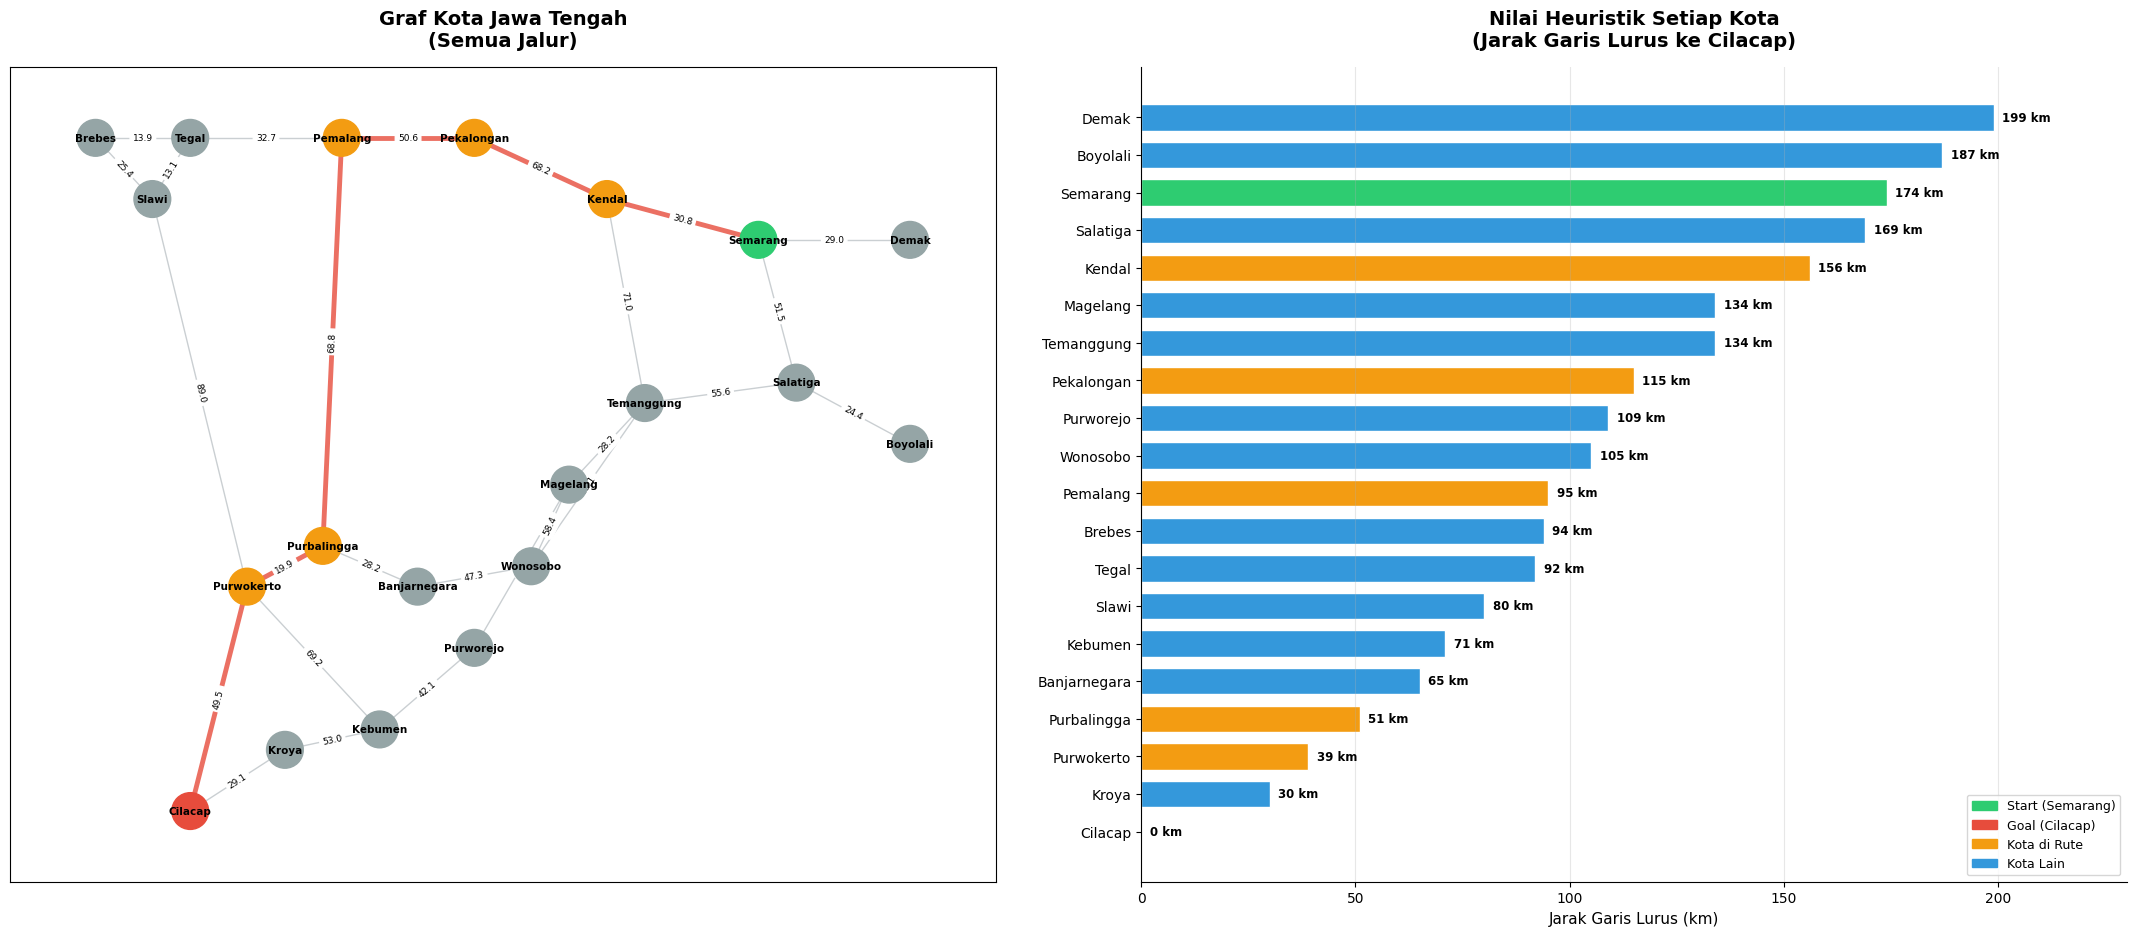


✅ Visualisasi berhasil disimpan sebagai 'rute_best_first_search.png'


In [ ]:
def visualisasi_graf(graph, rute, heuristic):
    fig, axes = plt.subplots(1, 2, figsize=(22, 10))

    # --- Koordinat kota (posisi pada peta Jawa Tengah) ---
    pos = {
        'Semarang':     (7.0,  4.0),
        'Demak':        (7.8,  4.0),
        'Kendal':       (6.2,  4.2),
        'Salatiga':     (7.2,  3.3),
        'Boyolali':     (7.8,  3.0),
        'Temanggung':   (6.4,  3.2),
        'Magelang':     (6.0,  2.8),
        'Wonosobo':     (5.8,  2.4),
        'Purworejo':    (5.5,  2.0),
        'Banjarnegara': (5.2,  2.3),
        'Purbalingga':  (4.7,  2.5),
        'Purwokerto':   (4.3,  2.3),
        'Kebumen':      (5.0,  1.6),
        'Kroya':        (4.5,  1.5),
        'Cilacap':      (4.0,  1.2),
        'Pekalongan':   (5.5,  4.5),
        'Pemalang':     (4.8,  4.5),
        'Tegal':        (4.0,  4.5),
        'Brebes':       (3.5,  4.5),
        'Slawi':        (3.8,  4.2),
    }

    G = nx.Graph()
    for kota1, neighbors in graph.items():
        for kota2, jarak in neighbors.items():
            G.add_edge(kota1, kota2, weight=jarak)

    rute_edges = [(rute[i], rute[i+1]) for i in range(len(rute)-1)]

    # Warna node
    node_colors = []
    for node in G.nodes():
        if node == 'Semarang':  node_colors.append('#2ecc71')   # hijau = start
        elif node == 'Cilacap': node_colors.append('#e74c3c')   # merah = goal
        elif node in rute:      node_colors.append('#f39c12')   # oranye = rute
        else:                   node_colors.append('#95a5a6')   # abu = tidak dilalui

    # --- SUBPLOT 1: Graf Lengkap ---
    ax1 = axes[0]
    ax1.set_title('Graf Kota Jawa Tengah\n(Semua Jalur)', fontsize=14, fontweight='bold', pad=15)

    edge_colors_all = ['#e74c3c' if (e in rute_edges or (e[1],e[0]) in rute_edges)
                       else '#bdc3c7' for e in G.edges()]
    edge_widths_all = [3.5 if (e in rute_edges or (e[1],e[0]) in rute_edges)
                       else 1.0 for e in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, ax=ax1)
    nx.draw_networkx_labels(G, pos, font_size=7.5, font_weight='bold', ax=ax1)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors_all, width=edge_widths_all, ax=ax1, alpha=0.8)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6.5, ax=ax1)

    # --- SUBPLOT 2: Heuristik per kota ---
    ax2 = axes[1]
    ax2.set_title('Nilai Heuristik Setiap Kota\n(Jarak Garis Lurus ke Cilacap)', fontsize=14, fontweight='bold', pad=15)

    kota_sorted = sorted(heuristic.items(), key=lambda x: x[1])
    kota_names  = [k for k,v in kota_sorted]
    kota_values = [v for k,v in kota_sorted]
    bar_colors  = ['#e74c3c' if k == 'Cilacap' else
                   '#2ecc71' if k == 'Semarang' else
                   '#f39c12' if k in rute else '#3498db'
                   for k,v in kota_sorted]

    bars = ax2.barh(kota_names, kota_values, color=bar_colors, edgecolor='white', height=0.7)
    for bar, val in zip(bars, kota_values):
        ax2.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 f'{val} km', va='center', fontsize=8.5, fontweight='bold')
    ax2.set_xlabel('Jarak Garis Lurus (km)', fontsize=11)
    ax2.set_xlim(0, 230)
    ax2.grid(axis='x', alpha=0.3)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Legend
    legend_els = [
        mpatches.Patch(color='#2ecc71', label='Start (Semarang)'),
        mpatches.Patch(color='#e74c3c', label='Goal (Cilacap)'),
        mpatches.Patch(color='#f39c12', label='Kota di Rute'),
        mpatches.Patch(color='#3498db', label='Kota Lain'),
    ]
    ax2.legend(handles=legend_els, loc='lower right', fontsize=9)

    plt.tight_layout(pad=3)
    plt.savefig('rute_best_first_search.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Visualisasi berhasil disimpan sebagai 'rute_best_first_search.png'")

visualisasi_graf(graph, rute, heuristic)

Bagian ini bikin dua visualisasi sekaligus biar lebih mudah dipahami. **Grafik kiri** nampilin peta graf semua kota di Jawa Tengah dengan rute yang ditemukan ditandai warna merah tebal. **Grafik kanan** nampilin bar chart nilai heuristik tiap kota — jadi keliatan jelas kenapa algoritma milih jalur tertentu, karena dia selalu 'menarik' ke kota yang garisnya paling pendek ke Cilacap. Warna hijau untuk titik awal, merah untuk tujuan, dan oranye untuk kota-kota yang dilewatin.

---
## 7. Tabel Rekap Proses Eksplorasi

In [ ]:
print("=" * 60)
print("📊 REKAP URUTAN EKSPLORASI KOTA")
print("=" * 60)
print(f"{'No':<5} {'Kota Dikunjungi':<20} {'h(n) km':<12} {'Status'}")
print("-" * 60)

for i, (kota, h_val, jalur) in enumerate(log, 1):
    if kota == 'Semarang':
        status = "🟢 START"
    elif kota == 'Cilacap':
        status = "🔴 GOAL ← DITEMUKAN!"
    elif kota in rute:
        status = "🟡 Di jalur terpilih"
    else:
        status = "⚪ Dieksplorasi"
    print(f"{i:<5} {kota:<20} {h_val:<12} {status}")

print("-" * 60)
print(f"\n📌 Kesimpulan:")
print(f"   Rute terbaik menurut Best First Search:")
print(f"   {' → '.join(rute)}")
print(f"   Total jarak nyata: {sum(graph[rute[i]][rute[i+1]] for i in range(len(rute)-1)):.1f} km")

📊 REKAP URUTAN EKSPLORASI KOTA
No    Kota Dikunjungi      h(n) km      Status
------------------------------------------------------------
1     Semarang             174          🟢 START
2     Kendal               156          🟡 Di jalur terpilih
3     Pekalongan           115          🟡 Di jalur terpilih
4     Pemalang             95           🟡 Di jalur terpilih
5     Purbalingga          51           🟡 Di jalur terpilih
6     Purwokerto           39           🟡 Di jalur terpilih
7     Cilacap              0            🔴 GOAL ← DITEMUKAN!
------------------------------------------------------------

📌 Kesimpulan:
   Rute terbaik menurut Best First Search:
   Semarang → Kendal → Pekalongan → Pemalang → Purbalingga → Purwokerto → Cilacap
   Total jarak nyata: 287.8 km


Tabel ini nampilin **rekap lengkap proses eksplorasi** dari awal sampe akhir. Kita bisa liat urutan kota mana yang dikunjungi duluan, berapa nilai heuristiknya, dan apakah kota itu masuk ke jalur terpilih atau cuma dieksplorasi aja. Ini berguna banget buat ngerti alur pikir algoritma Best First Search secara step-by-step — bukan cuma liat hasilnya, tapi ngerti *kenapa* dia milih jalur itu.